<a href="https://colab.research.google.com/github/salih-salu/Speech_Emotion_Recognition_using_AudioFiles/blob/main/Speech_Emotion_Recognition_Using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import os
import glob

import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.callbacks import ModelCheckpoint

#Get the Dataset through google drive mounting

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
Dataset_path = '/content/drive/MyDrive/Speech_Emotion_Recognition/Speech_emo_dataset'
print(os.listdir(Dataset_path))

['train_set', 'test_set']


In [4]:
train_path = os.path.join(Dataset_path, 'train_set')
test_path = os.path.join(Dataset_path, 'test_set')

print(os.listdir(train_path))
print(os.listdir(test_path))

['Actor_18', 'Actor_14', 'Actor_17', 'Actor_19', 'Actor_16', 'Actor_15', 'Actor_12', 'Actor_11', 'Actor_10', 'Actor_08', 'Actor_05', 'Actor_09', 'Actor_06', 'Actor_04', 'Actor_07', 'Actor_13', 'Actor_03', 'Actor_01', 'Actor_02']
['Actor_22', 'Actor_24', 'Actor_23', 'Actor_20', 'Actor_21']


#Used glob to find all audio files from the dataset

In [5]:
train_files = glob.glob(
    train_path + '/**/*.wav',
    recursive=True
)

test_files = glob.glob(
    test_path + '/**/*.wav',
    recursive=True
)

In [6]:
print(len(train_files), len(test_files))

1140 300


In [7]:
emotion_labels = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

In [8]:
def get_emotion(file_path):
    filename = os.path.basename(file_path)
    emotion_code = filename.split("-")[2]
    return emotion_labels[emotion_code]

In [9]:
#test emotion label using sample file from train_file

print(train_files[0])
print(get_emotion(train_files[0]))

#test emotion label using sample file from test_file

print(test_files[1])
print(get_emotion(test_files[1]))

/content/drive/MyDrive/Speech_Emotion_Recognition/Speech_emo_dataset/train_set/Actor_18/03-01-03-01-01-01-18.wav
happy
/content/drive/MyDrive/Speech_Emotion_Recognition/Speech_emo_dataset/test_set/Actor_22/03-01-06-02-01-01-22.wav
fearful


#Just create the DataFrame with Audio files paths and its related labels

In [10]:
train_df = pd.DataFrame({
    'file_path': train_files
})

test_df = pd.DataFrame({
    'file_path': test_files
})

In [11]:
# train_df

In [12]:
train_df['emotion'] = train_df['file_path'].apply(get_emotion)

In [13]:
train_df

,file_path,emotion
0,/content/drive/MyDrive/Speech_Emotion_Recognit...,happy
1,/content/drive/MyDrive/Speech_Emotion_Recognit...,calm
2,/content/drive/MyDrive/Speech_Emotion_Recognit...,calm
3,/content/drive/MyDrive/Speech_Emotion_Recognit...,sad
4,/content/drive/MyDrive/Speech_Emotion_Recognit...,neutral
...,...,...
1135,/content/drive/MyDrive/Speech_Emotion_Recognit...,surprised
1136,/content/drive/MyDrive/Speech_Emotion_Recognit...,disgust
1137,/content/drive/MyDrive/Speech_Emotion_Recognit...,surprised
1138,/content/drive/MyDrive/Speech_Emotion_Recognit...,disgust


In [14]:
test_df["emotion"] = test_df["file_path"].apply(get_emotion)

In [15]:
test_df

,file_path,emotion
0,/content/drive/MyDrive/Speech_Emotion_Recognit...,neutral
1,/content/drive/MyDrive/Speech_Emotion_Recognit...,fearful
2,/content/drive/MyDrive/Speech_Emotion_Recognit...,fearful
3,/content/drive/MyDrive/Speech_Emotion_Recognit...,fearful
4,/content/drive/MyDrive/Speech_Emotion_Recognit...,fearful
...,...,...
295,/content/drive/MyDrive/Speech_Emotion_Recognit...,fearful
296,/content/drive/MyDrive/Speech_Emotion_Recognit...,calm
297,/content/drive/MyDrive/Speech_Emotion_Recognit...,calm
298,/content/drive/MyDrive/Speech_Emotion_Recognit...,surprised


In [16]:
print(train_df["emotion"].value_counts())

emotion
happy        152
calm         152
sad          152
fearful      152
surprised    152
angry        152
disgust      152
neutral       76
Name: count, dtype: int64


In [17]:
print(test_df["emotion"].value_counts())

emotion
fearful      40
sad          40
calm         40
angry        40
happy        40
disgust      40
surprised    40
neutral      20
Name: count, dtype: int64


#Audio processing

taken one sample audio for visualize the audio wave

In [18]:
file_path = train_df.iloc[0]["file_path"]
print(file_path)

audio, sample_rate = librosa.load(
    file_path,
    sr=16000
)

print("Sample rate:", sample_rate)
print("Audio length:", len(audio))

/content/drive/MyDrive/Speech_Emotion_Recognition/Speech_emo_dataset/train_set/Actor_18/03-01-03-01-01-01-18.wav
Sample rate: 16000
Audio length: 54455


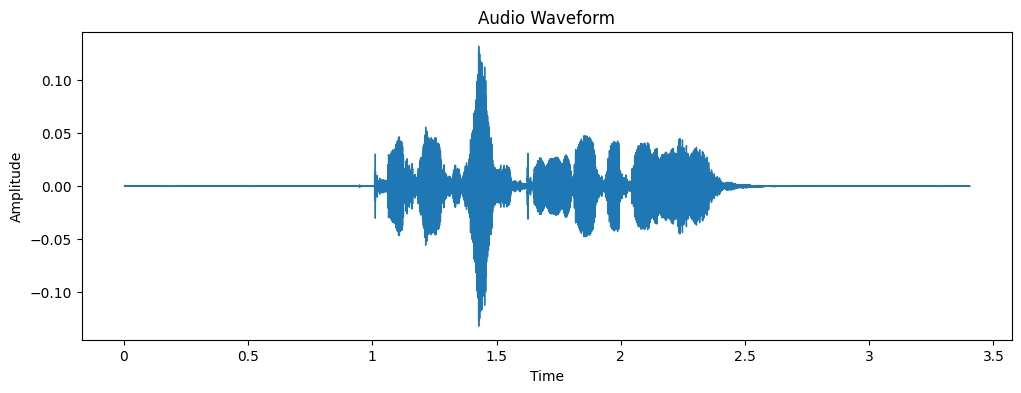

In [19]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    audio,
    sr=sample_rate
)

plt.title("Audio Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

In [20]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

print(mfcc.shape)

(40, 107)


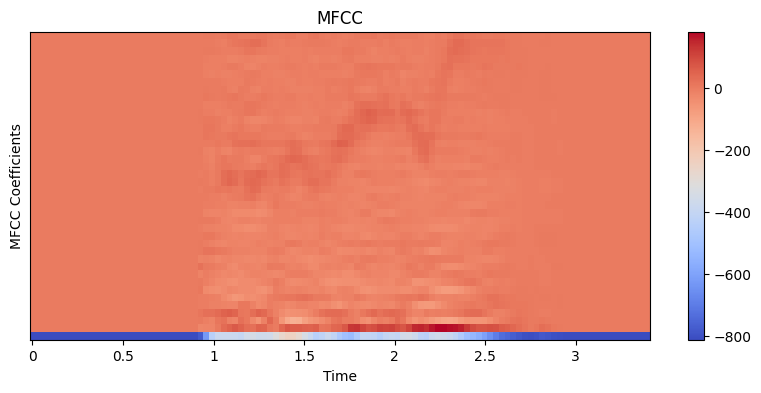

In [21]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sample_rate
)

plt.colorbar()
plt.title("MFCC")
plt.ylabel("MFCC Coefficients")
plt.xlabel("Time")
plt.show()

#Data augmentation functions

In [22]:
def add_noise(audio, noise_factor=0.005):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise


def shift_audio(audio, shift_max=0.2):
    shift = int(np.random.uniform(-shift_max, shift_max) * len(audio))
    return np.roll(audio, shift)


def change_pitch(audio, sr, n_steps=2):
    return librosa.effects.pitch_shift(
        y=audio,
        sr=sr,
        n_steps=n_steps
    )

#MFCC Extraction for all audio files

Mel Frequency Cepstral Coefficients

In [23]:
def extract_mfcc(file_path, n_mfcc=40, max_pad_len=174):
    audio, sample_rate = librosa.load(
        file_path,
        sr=16000
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=n_mfcc
    )

    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(
            mfcc,
            pad_width=((0, 0), (0, pad_width)),
            mode='constant'
        )
    else:
        mfcc = mfcc[:, :max_pad_len]

    return mfcc

# ........................................................................................................
# ........................................................................................................


def extract_mfcc_augmented(file_path, n_mfcc=40, max_pad_len=174):

    audio, sr = librosa.load(
        file_path,
        sr=16000
    )

    # Randomly choose one augmentation
    choice = np.random.choice(
        ["original", "noise", "shift", "pitch"]
    )

    if choice == "noise":
        audio = add_noise(audio)

    elif choice == "shift":
        audio = shift_audio(audio)

    elif choice == "pitch":
        audio = change_pitch(audio, sr, n_steps=2)

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=n_mfcc
    )

    # Padding / trimming
    if mfcc.shape[1] < max_pad_len:

        pad_width = max_pad_len - mfcc.shape[1]

        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, pad_width)),
            mode='constant'
        )

    else:
        mfcc = mfcc[:, :max_pad_len]

    return mfcc

Create X_train and y_train

In [24]:
# X_train = []
# y_train = []

# for file_path in train_df["file_path"]:
#     # print(file_path)
#     mfcc = extract_mfcc(file_path)

#     X_train.append(mfcc)

#     emotion = get_emotion(file_path)
#     y_train.append(emotion)

X_train_aug = []
y_train_aug = []

for file_path in train_df["file_path"]:

    # Original audio
    mfcc = extract_mfcc_augmented(file_path)

    X_train_aug.append(mfcc)
    y_train_aug.append(get_emotion(file_path))

    # One additional augmented version
    mfcc_aug = extract_mfcc_augmented(file_path)

    X_train_aug.append(mfcc_aug)
    y_train_aug.append(get_emotion(file_path))


X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

print("X_train_aug:", X_train_aug.shape)
print("y_train_aug:", y_train_aug.shape)

X_train_aug: (2280, 40, 174)
y_train_aug: (2280,)


In [25]:
# Calculate mean and standard deviation from training data only
mean = X_train_aug.mean()
std = X_train_aug.std()

# Normalize training and testing data
X_train = (X_train_aug - mean) / (std + 1e-8)
X_test = (X_train_aug - mean) / (std + 1e-8)

print("Before normalization:")
print("Mean:", X_train_aug.mean())
print("Std:", X_train_aug.std())

print("\nAfter normalization:")
print("Mean:", X_train.mean())
print("Std:", X_train.std())

Before normalization:
Mean: -8.261726557008956
Std: 72.12714312539177

After normalization:
Mean: -3.607161398015834e-18
Std: 0.9999999998613551


Converting (X_train and y_train) List to array

In [26]:
# X_train = np.array(X_train)
# y_train = np.array(y_train)

X_train = np.array(X_train_aug)
y_train = np.array(y_train_aug)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (2280, 40, 174)
y_train shape: (2280,)


Create X_test and y_test

In [27]:
X_test = []
y_test = []

for file_path in test_df["file_path"]:

    mfcc = extract_mfcc(file_path)

    X_test.append(mfcc)

    emotion = get_emotion(file_path)
    y_test.append(emotion)

In [28]:
X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (300, 40, 174)
y_test shape: (300,)


#Converting the emotion labels (output) to numbers using LabelEncoding

In [29]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

print(encoder.classes_)

['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [30]:
print(y_train)

[4 4 1 ... 2 7 7]


In [31]:
# print(y_test)

#Add CNN channel dimension

In [32]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape)
print(X_test.shape)

(2280, 40, 174, 1)
(300, 40, 174, 1)


In [33]:
# print(X_train)

In [34]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(40, 174, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(8, activation='softmax'))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 40, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 20, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       983,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,076,872 (4.11 MB)

 Trainable params: 1,076,872 (4.11 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#Apply check point to save the best model

In [36]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [37]:
model.fit(X_train, y_train, batch_size=32, epochs=25, callbacks=[checkpoint])

Epoch 1/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.1921 - loss: 3.2288
Epoch 1: accuracy improved from None to 0.22281, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 403ms/step - accuracy: 0.2228 - loss: 2.2972
Epoch 2/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.3243 - loss: 1.7879
Epoch 2: accuracy improved from 0.22281 to 0.31711, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 411ms/step - accuracy: 0.3171 - loss: 1.7763
Epoch 3/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.3575 - loss: 1.6447
Epoch 3: accuracy improved from 0.31711 to 0.37675, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 361ms/step - accuracy: 0.3768 - loss: 1.6144
Epoch 4/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.4170 - loss: 1.5170
Epoch 4: accuracy im

In [38]:
# model.history.history

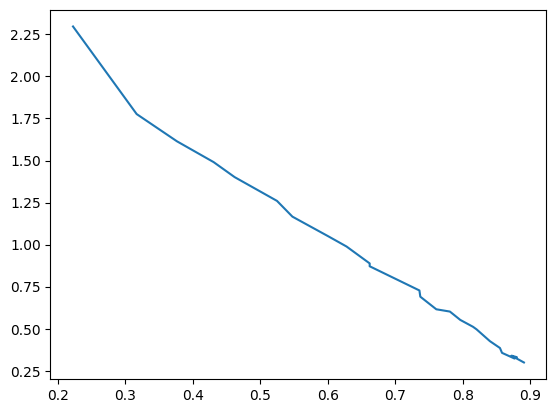

In [39]:
plt.plot(model.history.history['accuracy'], model.history.history['loss'])

#evaluate the model performance

In [40]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(test_loss, test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.5133 - loss: 4.0907
4.09066104888916 0.5133333206176758


In [41]:
y_pred = model.predict(X_test)
# for i in y_pred:
#   print(i)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step


In [42]:
y_pred_ind = y_pred.argmax(axis=1)
y_pred_ind

array([6, 3, 4, 4, 4, 6, 1, 6, 6, 1, 0, 1, 6, 6, 4, 0, 6, 6, 4, 3, 0, 6,
       6, 3, 0, 4, 1, 4, 0, 0, 1, 1, 4, 6, 6, 4, 6, 6, 5, 6, 0, 4, 4, 0,
       4, 0, 6, 0, 0, 0, 4, 0, 7, 7, 7, 7, 7, 7, 7, 7, 1, 5, 6, 6, 1, 1,
       2, 3, 0, 1, 5, 0, 2, 6, 0, 1, 5, 4, 6, 6, 1, 0, 3, 6, 1, 1, 0, 3,
       2, 1, 0, 6, 0, 0, 0, 5, 1, 6, 0, 2, 0, 0, 4, 1, 3, 2, 7, 2, 2, 7,
       7, 7, 0, 7, 4, 2, 7, 7, 2, 2, 1, 7, 2, 7, 7, 7, 0, 7, 0, 2, 7, 1,
       4, 2, 3, 0, 4, 7, 4, 6, 7, 4, 6, 5, 2, 6, 2, 4, 1, 1, 7, 6, 2, 2,
       5, 1, 4, 4, 0, 1, 0, 7, 3, 7, 1, 5, 0, 7, 5, 1, 0, 7, 7, 7, 7, 7,
       2, 7, 7, 7, 5, 1, 5, 5, 1, 1, 1, 1, 4, 1, 5, 5, 6, 4, 2, 0, 0, 2,
       7, 2, 0, 2, 4, 4, 0, 7, 1, 4, 6, 6, 7, 6, 4, 2, 6, 1, 4, 5, 2, 4,
       5, 2, 7, 2, 7, 7, 3, 0, 7, 3, 6, 4, 4, 4, 2, 0, 0, 5, 0, 4, 1, 6,
       1, 6, 1, 1, 1, 4, 0, 2, 2, 4, 0, 0, 2, 2, 7, 7, 0, 1, 0, 0, 2, 0,
       0, 7, 0, 0, 7, 2, 4, 7, 0, 7, 7, 0, 0, 0, 4, 2, 0, 0, 0, 0, 0, 6,
       6, 4, 0, 1, 6, 0, 1, 1, 0, 6, 1, 1, 7, 7])

#Classification Report

In [43]:
crp = classification_report(y_test, y_pred_ind)
print(crp)

              precision    recall  f1-score   support

           0       0.48      0.75      0.58        40
           1       0.66      0.72      0.69        40
           2       0.50      0.42      0.46        40
           3       0.45      0.12      0.20        40
           4       0.45      0.45      0.45        40
           5       0.35      0.30      0.32        20
           6       0.35      0.35      0.35        40
           7       0.69      0.88      0.77        40

    accuracy                           0.51       300
   macro avg       0.49      0.50      0.48       300
weighted avg       0.50      0.51      0.49       300



In [44]:
print(len(y_test), len(y_pred_ind))

300 300


In [45]:
print("Actual:   ", y_test[150])
print("Predicted: ", y_pred_ind[150])

Actual:    3
Predicted:  7


#Accuracy Score

In [46]:
accuracy = accuracy_score(y_test, y_pred_ind)
print('Accuracy: ', accuracy)

Accuracy:  0.5133333333333333


# Confusion Matrix

In [47]:
cm = confusion_matrix(y_test, y_pred_ind)
print(cm)

[[30  0  1  1  2  0  0  6]
 [ 0 29  2  0  0  3  6  0]
 [16  0 17  0  4  2  0  1]
 [ 7  2  4  5  8  2 10  2]
 [ 4  2  1  4 18  0  4  7]
 [ 1  5  0  0  2  6  6  0]
 [ 4  6  9  1  3  3 14  0]
 [ 1  0  0  0  3  1  0 35]]


In [48]:
labels = list(emotion_labels.values())
print(labels)

['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']


#Confusion Matrix Display

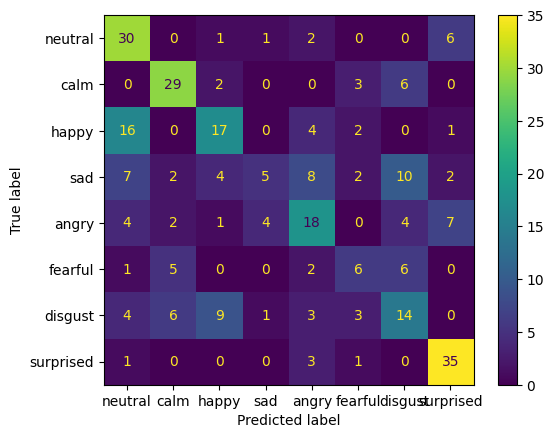

In [49]:
cmd = ConfusionMatrixDisplay(cm,display_labels=labels)
cmd.plot()

#Test an audio file via uploading.

In [50]:
# from google.colab import files

# uploaded = files.upload()

In [51]:
# def extract_mfcc_for_prediction(file_path, n_mfcc=40, max_pad_len=174):
#     audio, sample_rate = librosa.load(
#         file_path,
#         sr=16000
#     )
#     mfcc = librosa.feature.mfcc(
#         y=audio,
#         sr=sample_rate,
#         n_mfcc=n_mfcc
#     )

#     if mfcc.shape[1] < max_pad_len:
#         pad_width = max_pad_len - mfcc.shape[1]
#         mfcc = np.pad(
#             mfcc,
#             ((0, 0), (0, pad_width)),
#             mode='constant'
#         )
#     else:
#         mfcc = mfcc[:, :max_pad_len]

#     return mfcc

In [52]:
# # file_path = list(uploaded.keys())[0]
# file_path = '/content/03-01-08-02-02-01-21.wav'

# mfcc = extract_mfcc_for_prediction(file_path)
# mfcc = mfcc[np.newaxis, ..., np.newaxis]
# prediction = model.predict(mfcc)
# predicted_class = np.argmax(prediction, axis=1)[0]

# predicted_emotion = encoder.inverse_transform([predicted_class])[0]
# confidence = np.max(prediction) * 100

# print("Predicted Emotion:", predicted_emotion)
# print("Confidence:", round(confidence, 2), "%")

In [53]:
# The above prediction is correct for the uploaded audio file.

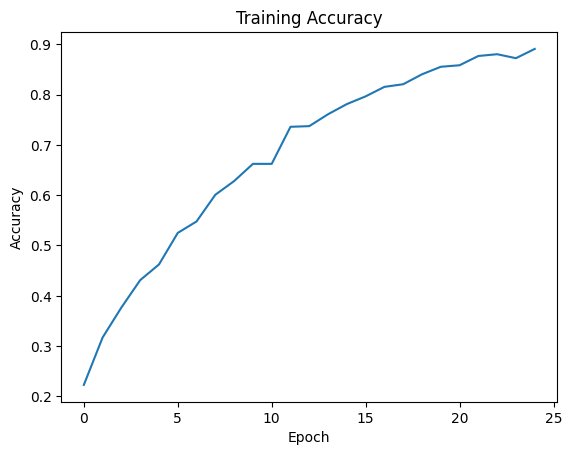

In [54]:
plt.plot(model.history.history['accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [55]:
train_accuracy = model.history.history['accuracy'][-1]

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.8907894492149353
Test Accuracy: 0.5133333206176758
